## 0. Pythonの基礎知識

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, poisson, cauchy

In [26]:
#変数の定義
x = 5
y = 10

# 変数の演算
z = x + y
print(f"z = {z}")

z = 15


In [27]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# 要素ごとの和
c = a + b
print(f"c = {c}")  # [5 7 9]

# 要素ごとの積（Hadamard積）
d = a * b
print(f"d = {d}")  # [ 4 10 18]

# 行列の内積（ドット積）
e = a @ b  # または np.dot(a, b)
print(f"e = {e}")  # 32


c = [5 7 9]
d = [ 4 10 18]
e = 32


In [29]:

# 関数定義
def f(u):
    return u**2

def g(u, v):
    return u + v

def h(u, v):
    return [u * v, u + v]

# 関数の呼び出し
print("f(x) =", f(x))            # 25
print("g(x, y) =", g(x, y))      # 15
print("h(x, y) =", h(x, y))      # [50, 15]

# ベクトルに対してブロードキャスト的に適用
print("f(a) =", f(a))            # [ 1  4  9]
print("g(a, b) =", g(a, b))      # [ 5  7  9]


f(x) = 25
g(x, y) = 15
h(x, y) = [50, 15]
f(a) = [1 4 9]
g(a, b) = [5 7 9]


In [30]:

# 配列の準備
a = np.arange(1, 11)          # 1から10までの整数 → [1 2 3 ... 10]
print("a =", a)

b = np.arange(0, 1.01, 0.01)  # 0.00〜1.00（両端含む）→ 101個
print("b =", b)

r = np.random.rand(10)        # 0〜1の一様乱数を10個
print("r =", r)

# 部分配列の取得
print("a[0:5] =", a[0:5])     # Pythonは0-based indexing → a[0:5] = [1 2 3 4 5]

a = [ 1  2  3  4  5  6  7  8  9 10]
b = [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99 1.  ]
r = [0.22015086 0.27519151 0.42339041 0.8812759  0.12037958 0.82756522
 0.06831012 0.35050704 0.00501026 0.6084571 ]
a[0:5] = [1 2 3 4 5]


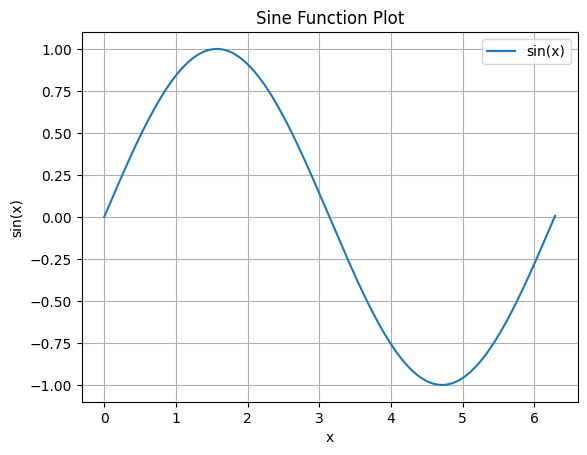

In [31]:
x_vals = np.arange(0, 2 * np.pi + 0.01, 0.01)
y_vals = np.sin(x_vals)

# グラフ描画
plt.plot(x_vals, y_vals, label="sin(x)")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Sine Function Plot")
plt.legend()
plt.grid(True)
plt.show()

## 1. 大数の法則

In [2]:
# 確率分布を定義
p = norm(loc=0, scale=1)
p1 = poisson(mu=1)
p2 = cauchy(loc=0, scale=1)

In [3]:
# サンプル数
n_sample = 500

# サンプルを生成
sample_n = p.rvs(size=n_sample)
sample_p = p1.rvs(size=n_sample)
sample_c = p2.rvs(size=n_sample)

In [4]:
# x軸の範囲を定義
xn = np.arange(-10.0, 10.0, 0.1)
xp = np.arange(0, 21, 1)
xc = np.arange(-10.0, 10.0, 0.1)

# PDFを計算
pd = p.pdf(xn)
pd1 = p1.pmf(xp)
pd2 = p2.pdf(xc)

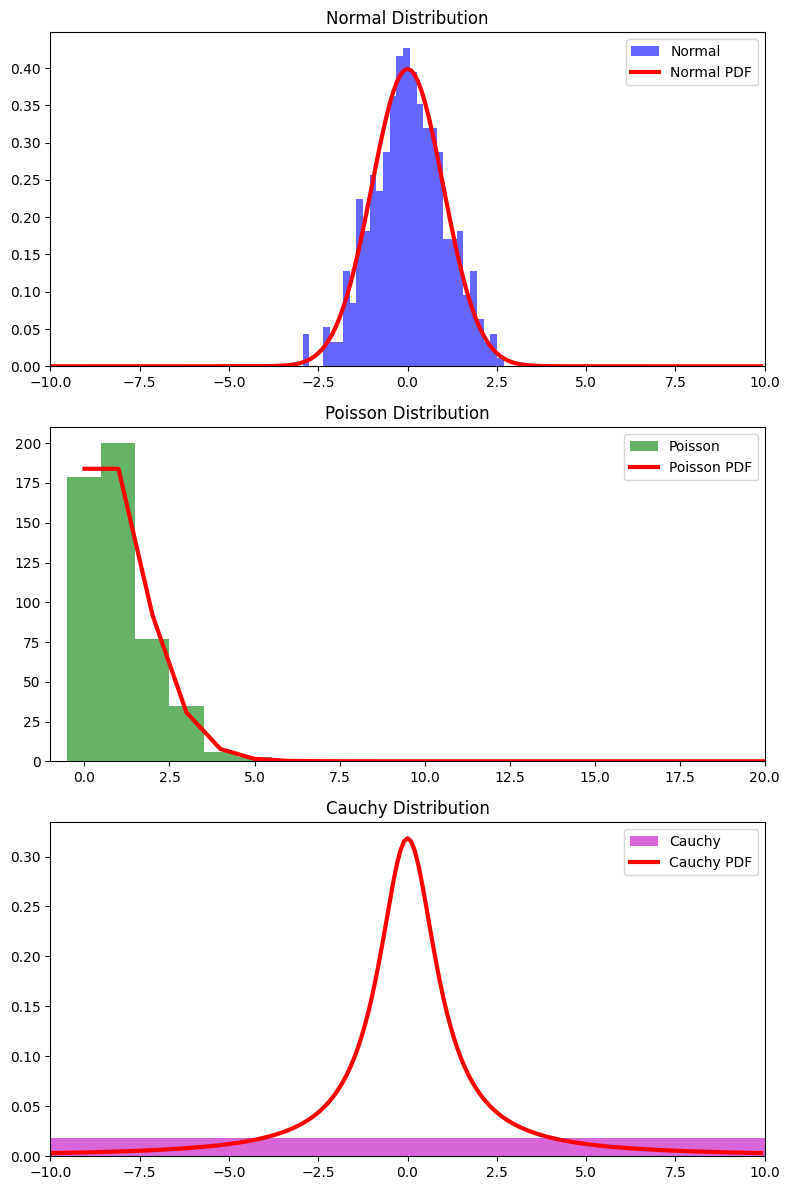

In [5]:
# グラフ描画
fig, axs = plt.subplots(3, 1, figsize=(8, 12))

# 正規分布のヒストグラムとPDF
axs[0].hist(sample_n, bins=30, density=True, alpha=0.6, color='b', label="Normal")
axs[0].plot(xn, pd, 'r-', lw=3, label="Normal PDF")
axs[0].set_xlim(-10, 10)
axs[0].legend(loc='upper right')
axs[0].set_title("Normal Distribution")

# ポアソン分布のヒストグラムとPDF
axs[1].hist(sample_p, bins=np.arange(-0.5, 21.5, 1), alpha=0.6, color='g', label="Poisson", density=False)
axs[1].plot(xp, n_sample * pd1, 'r-', lw=3, label="Poisson PDF")
axs[1].set_xlim(-1, 20)
axs[1].legend(loc='upper right')
axs[1].set_title("Poisson Distribution")

# コーシー分布のヒストグラムとPDF
axs[2].hist(sample_c, bins=30, density=True, alpha=0.6, color='m', label="Cauchy")
axs[2].plot(xc, pd2, 'r-', lw=3, label="Cauchy PDF")
axs[2].set_xlim(-10, 10)
axs[2].legend(loc='upper right')
axs[2].set_title("Cauchy Distribution")

# グラフのレイアウト調整
plt.tight_layout()
plt.show()

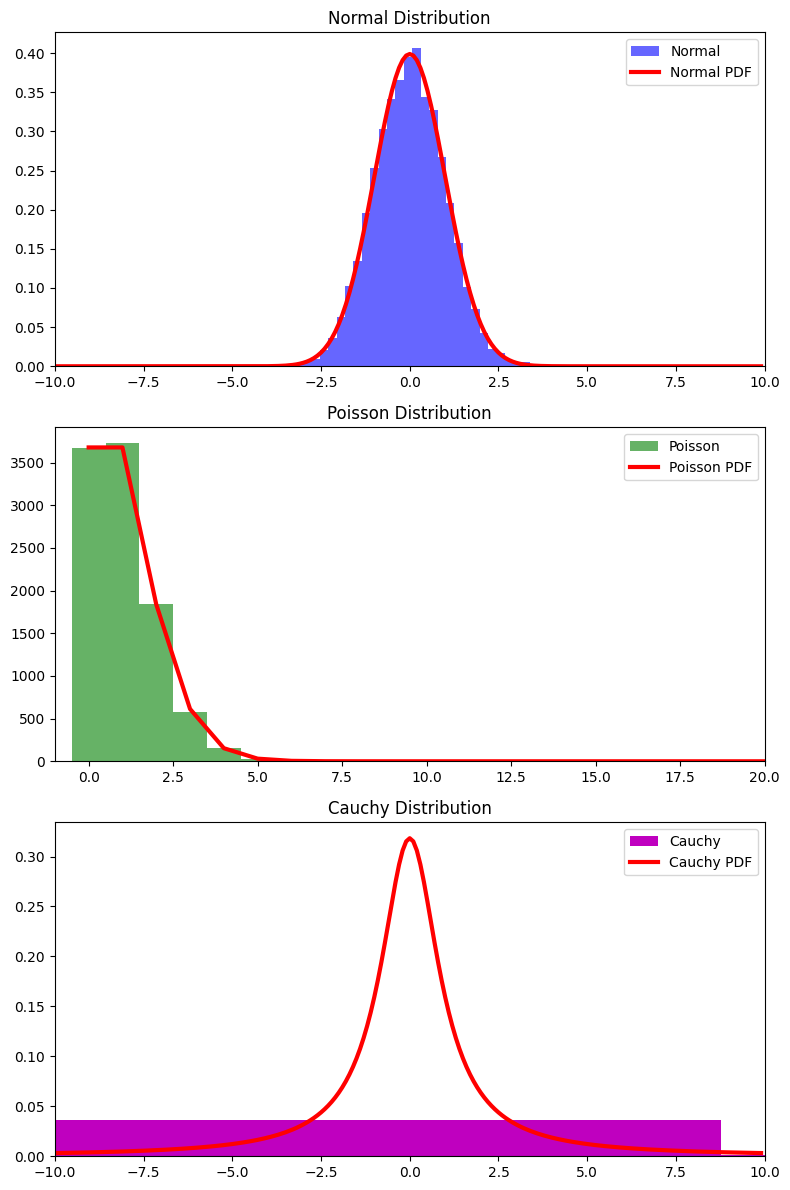

In [6]:
n_sample = 10000

# サンプルを生成
sample_n = p.rvs(size=n_sample)
sample_p = p1.rvs(size=n_sample)
sample_c = p2.rvs(size=n_sample)

fig, axs = plt.subplots(3, 1, figsize=(8, 12))

# 正規分布のヒストグラムとPDF
axs[0].hist(sample_n, bins=30, density=True, alpha=0.6, color='b', label="Normal")
axs[0].plot(xn, pd, 'r-', lw=3, label="Normal PDF")
axs[0].set_xlim(-10, 10)
axs[0].legend(loc='upper right')
axs[0].set_title("Normal Distribution")

# ポアソン分布のヒストグラムとPDF
axs[1].hist(sample_p, bins=np.arange(-0.5, 21.5, 1), alpha=0.6, color='g', label="Poisson", density=False)
axs[1].plot(xp, n_sample * pd1, 'r-', lw=3, label="Poisson PDF")
axs[1].set_xlim(-1, 20)
axs[1].legend(loc='upper right')
axs[1].set_title("Poisson Distribution")

# コーシー分布のヒストグラムとPDF
axs[2].hist(sample_c, bins=200, density=True, color='m', label="Cauchy")
axs[2].plot(xc, pd2, 'r-', lw=3, label="Cauchy PDF")
axs[2].set_xlim(-10, 10)
axs[2].legend(loc='upper right')
axs[2].set_title("Cauchy Distribution")

# グラフのレイアウト調整
plt.tight_layout()
plt.show()

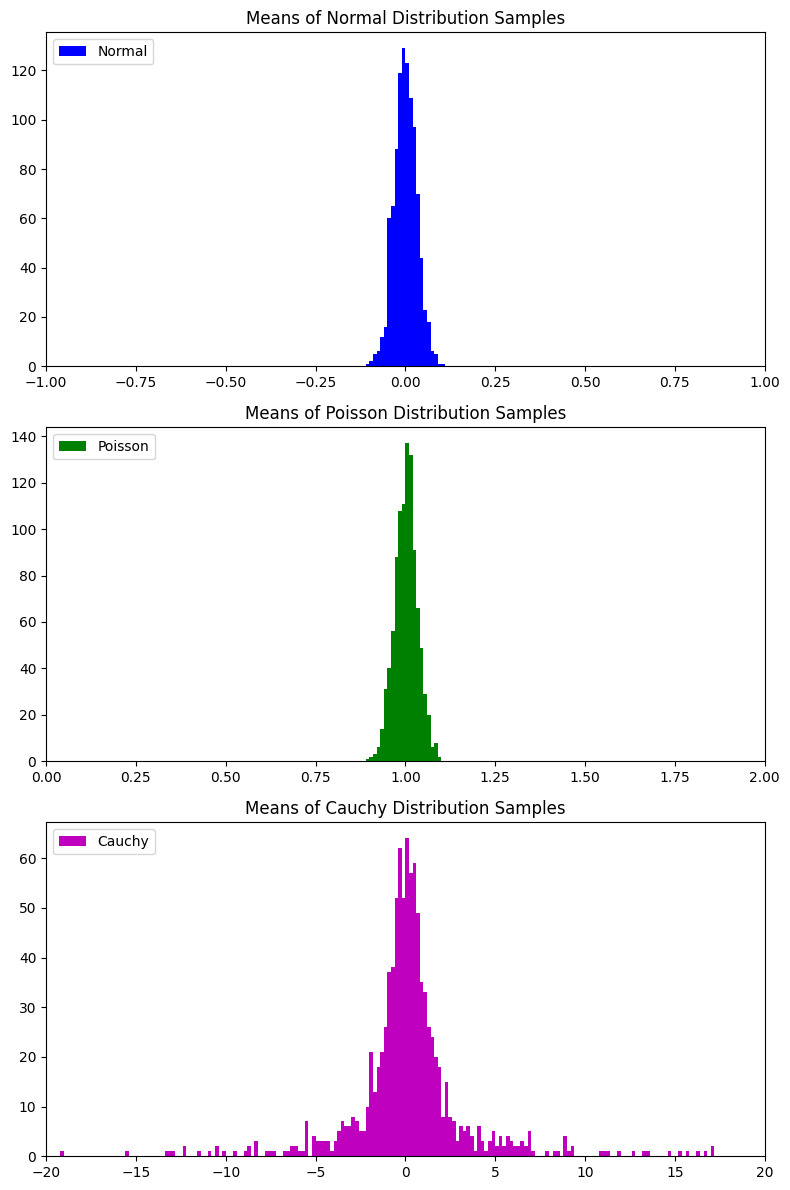

In [7]:
n_trial = 1000
n_sample = 1000

# 平均を保存するための配列を初期化
normal_means = np.zeros(n_trial)
poisson_means = np.zeros(n_trial)
cauchy_means = np.zeros(n_trial)

# 試行を繰り返して各分布の平均を計算
for it in range(n_trial):
    # サンプリング
    normal_means[it] = np.mean(norm.rvs(size=n_sample))
    poisson_means[it] = np.mean(poisson.rvs(mu=1, size=n_sample))
    cauchy_means[it] = np.mean(cauchy.rvs(size=n_sample))

# グラフ描画
fig, axs = plt.subplots(3, 1, figsize=(8, 12))

# 正規分布の平均値のヒストグラム
axs[0].hist(normal_means, bins=200, range=(-1.0, 1.0), color='b', label="Normal")
axs[0].legend(loc='upper left')
axs[0].set_xlim(-1, 1)
axs[0].set_title("Means of Normal Distribution Samples")

# ポアソン分布の平均値のヒストグラム
axs[1].hist(poisson_means, bins=200, range=(0.0, 2.0), color='g', label="Poisson")
axs[1].legend(loc='upper left')
axs[1].set_xlim(0, 2)
axs[1].set_title("Means of Poisson Distribution Samples")

# コーシー分布の平均値のヒストグラム
axs[2].hist(cauchy_means, bins=200, range=(-20.0, 20.0), color='m', label="Cauchy")
axs[2].legend(loc='upper left')
axs[2].set_xlim(-20, 20)
axs[2].set_title("Means of Cauchy Distribution Samples")

# グラフのレイアウト調整
plt.tight_layout()
plt.show()

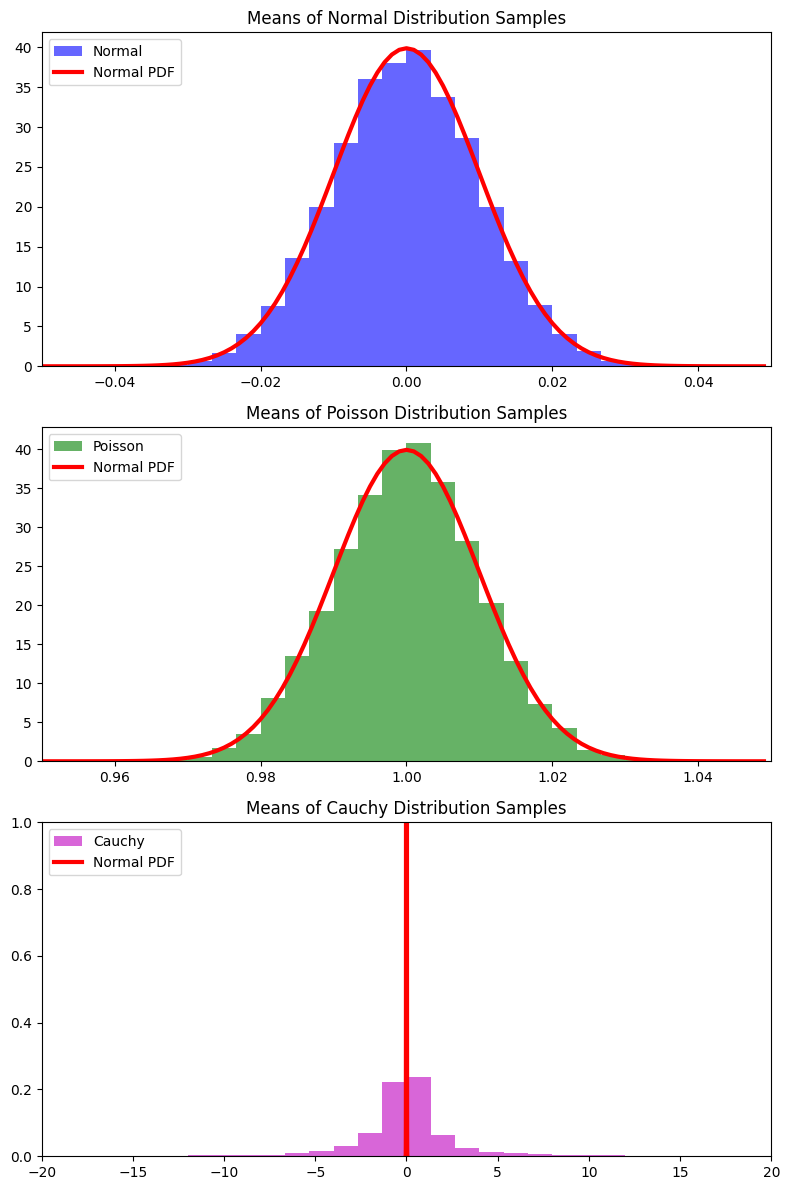

In [8]:
# パラメータ設定
n_trial = 10000
n_sample = 10000

# 平均を保存するための配列を初期化
normal_means = np.zeros(n_trial)
poisson_means = np.zeros(n_trial)
cauchy_means = np.zeros(n_trial)

# 試行を繰り返して各分布の平均を計算
for it in range(n_trial):
    # サンプリング
    normal_means[it] = np.mean(norm.rvs(size=n_sample))
    poisson_means[it] = np.mean(poisson.rvs(mu=1, size=n_sample))
    cauchy_means[it] = np.mean(cauchy.rvs(size=n_sample))

# 平均の標準偏差
ns = np.sqrt(n_sample)

# x軸の範囲を定義
xnn = np.arange(-5.0/ns, 5.0/ns, 0.1/ns)

# グラフ描画
fig, axs = plt.subplots(3, 1, figsize=(8, 12))

# 正規分布の平均値のヒストグラムと理論値
axs[0].hist(normal_means, bins=30, range=(-5.0/ns, 5.0/ns), density=True, alpha=0.6, color='b', label="Normal")
axs[0].plot(xnn, norm.pdf(xnn, 0, 1/ns), 'r-', lw=3, label="Normal PDF")
axs[0].legend(loc='upper left')
axs[0].set_xlim(-5.0/ns, 5.0/ns)
axs[0].set_title("Means of Normal Distribution Samples")

# ポアソン分布の平均値のヒストグラムと理論値
axs[1].hist(poisson_means, bins=30, range=(1.0-5.0/ns, 1.0+5.0/ns), density=True, alpha=0.6, color='g', label="Poisson")
axs[1].plot(1.0 + xnn, norm.pdf(1.0 + xnn, 1, 1/ns), 'r-', lw=3, label="Normal PDF")
axs[1].legend(loc='upper left')
axs[1].set_xlim(1.0-5.0/ns, 1.0+5.0/ns)
axs[1].set_title("Means of Poisson Distribution Samples")

# コーシー分布の平均値のヒストグラムと理論値
axs[2].hist(cauchy_means, bins=30, range=(-20.0, 20.0), density=True, alpha=0.6, color='m', label="Cauchy")
axs[2].plot(xnn, norm.pdf(xnn, 0, 1/ns), 'r-', lw=3, label="Normal PDF")
axs[2].legend(loc='upper left')
axs[2].set_xlim(-20.0, 20.0)
axs[2].set_ylim(0.0, 1.0)
axs[2].set_title("Means of Cauchy Distribution Samples")

# グラフのレイアウト調整
plt.tight_layout()
plt.show()

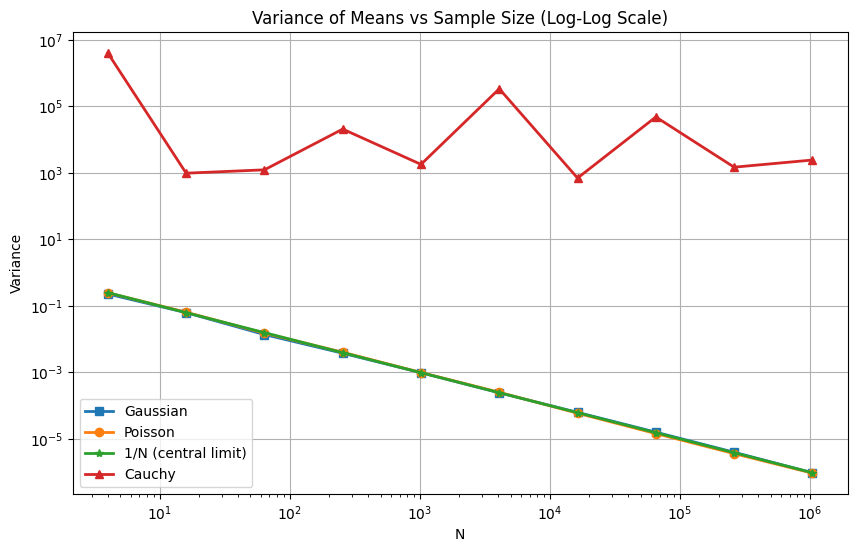

In [9]:
# 中心極限定理の関数
def central_limit_theorem(n_sample, n_trial):
    normal_means = np.zeros(n_trial)
    poisson_means = np.zeros(n_trial)
    cauchy_means = np.zeros(n_trial)
    for it in range(n_trial):
        # サンプリング
        normal_means[it] = np.mean(norm.rvs(size=n_sample))
        poisson_means[it] = np.mean(poisson.rvs(mu=1, size=n_sample))
        cauchy_means[it] = np.mean(cauchy.rvs(size=n_sample))
    return (np.mean(normal_means), np.mean(poisson_means), np.mean(cauchy_means),
            np.var(normal_means), np.var(poisson_means), np.var(cauchy_means))

# 実験のパラメータ
N = 10
var_normal = np.zeros(N)
var_poisson = np.zeros(N)
var_cauchy = np.zeros(N)
mean_normal = np.zeros(N)
mean_poisson = np.zeros(N)
mean_cauchy = np.zeros(N)

# サンプルサイズのリスト
n_samples = [4**i for i in range(1, N + 1)]

# 実験を実行
for i, n_sample in enumerate(n_samples):
    n_trial = 1000
    mean_normal[i], mean_poisson[i], mean_cauchy[i], var_normal[i], var_poisson[i], var_cauchy[i] = central_limit_theorem(n_sample, n_trial)

# プロット
plt.figure(figsize=(10, 6))
plt.plot(n_samples, var_normal, marker='s', label="Gaussian", linestyle='-', linewidth=2)
plt.plot(n_samples, var_poisson, marker='o', label="Poisson", linestyle='-', linewidth=2)
plt.plot(n_samples, 1.0 / np.array(n_samples, dtype=np.float64), marker='*', label="1/N (central limit)", linestyle='-', linewidth=2)
plt.plot(n_samples, var_cauchy, marker='^', label="Cauchy", linestyle='-', linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("N")
plt.ylabel("Variance")
plt.legend(loc='lower left')
plt.title("Variance of Means vs Sample Size (Log-Log Scale)")
plt.grid(True)
plt.show()


## 典型性の実験

あんまり教育的ではないかもしれないが自明な例を考えてみる
$$
H = 0
$$
である$S = \pm 1$の１次元スピン系を考える。

例えば、考える物理量として反強磁性秩序パラメータ$\frac{1}{N}\sum_i<S_iS_i+1>$を考える。これは、$H=0$が与えるミクロカノニカル分布において期待値0である。ランダムに生成した状態におけるこの期待値がミクロカノニカル分布にどれくらい近いのかを確かめてみよう

In [10]:
def bool2int(b):
    return 1 if b else -1  # trueなら1, falseなら-1を返す

# 1つの状態における反強磁性秩序パラメータの値を返す
def af_order(state):
    return sum(state[i] * state[i+1] for i in range(len(state) - 1)) / (len(state) - 1)


In [11]:

N = 1000  # スピンの数
n_sample = 100  # サンプル数

# -1, 1の値を持つのでBool型(true/false)で表現
state = np.random.choice([1, -1], (n_sample, N))

# 1つの状態における反強磁性秩序パラメータの値を計算
value = [af_order(state[i, :]) for i in range(n_sample)]


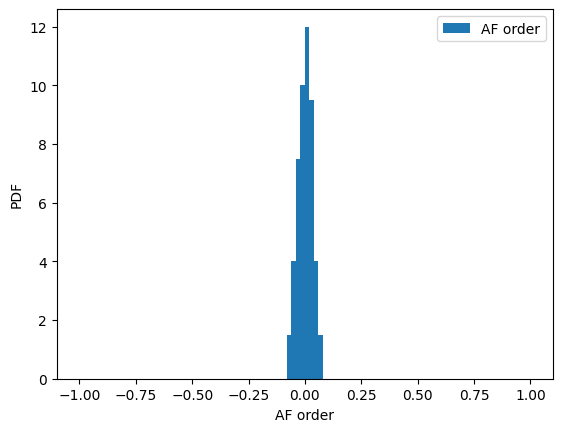

In [12]:
#import matplotlib.pyplot as plt

# ヒストグラムをプロット
plt.hist(value, bins=100, range=(-1, 1), density=True, label="AF order")

# 軸ラベルを設定
plt.xlabel("AF order")
plt.ylabel("PDF")

# 凡例を表示
plt.legend()

# プロットを表示
plt.show()

In [13]:
def typicality(N, n_sample):
    state = np.random.choice([1, -1], (n_sample, N))
    value = [af_order(state[i,:]) for i in range(n_sample)]
    return value

In [14]:
Ns = [10, 100, 1000]
n_sample = 500
results = []

for N in Ns:
    results.append(typicality(N, n_sample))

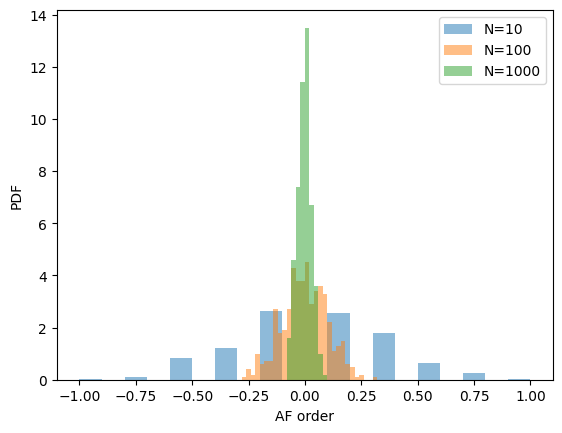

In [15]:

# ヒストグラムをプロット
plt.hist(results[0], range=(-1, 1), bins=20, density=True, alpha=0.5, label="N=10")
plt.hist(results[1], range=(-1, 1), bins=100, density=True, alpha=0.5, label="N=100")
plt.hist(results[2], range=(-1, 1), bins=100, density=True, alpha=0.5, label="N=1000")

# 軸ラベルを設定
plt.xlabel("AF order")
plt.ylabel("PDF")

# 凡例を表示
plt.legend()

# プロットを表示
plt.show()

## Sanovの定理

In [16]:
from scipy.stats import rv_discrete

# 真の分布 P
P = np.array([0.5, 0.5])
n = 100
num_trials = 10**5

# KL divergence: D_KL(P || Q)
def D_KL(Ps, Qs):
    Ps = np.asarray(Ps, dtype=np.float64)
    Qs = np.asarray(Qs, dtype=np.float64)
    mask = Ps > 0
    return np.sum(Ps[mask] * np.log(Ps[mask] / Qs[mask]))

# サンプリングによる経験分布の収集
values = [1, 2]  # 経験分布の support（1: index 0, 2: index 1）
dist = rv_discrete(name='d', values=(values, P))

exp_probs = []  # 経験分布 p_1 の履歴を記録
for _ in range(num_trials):
    sample = dist.rvs(size=n)
    counts = np.array([(sample == 1).sum(), (sample == 2).sum()])
    emp_dist = counts / n
    exp_probs.append(emp_dist[0])  # p1 のみ保存

# Sanovの定理による指数的確率評価
p1_range = np.arange(0.0, 1.01, 0.01)
kl_p1 = [np.exp(-n * D_KL([p, 1 - p], P)) for p in p1_range]
s = sum(kl_p1) / n

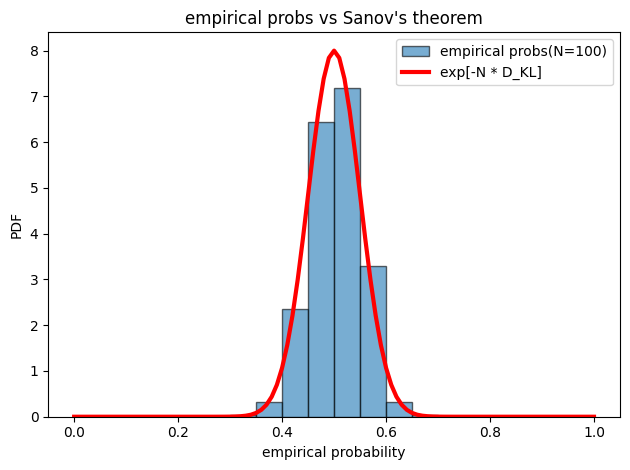

In [18]:
# ヒストグラム：経験分布
plt.hist(exp_probs, bins=20, range=(0, 1), density=True,
         label="empirical probs(N=100)", alpha=0.6, edgecolor='black')

# Sanovの理論分布を重ねる
plt.plot(p1_range, np.array(kl_p1) / s, lw=3,
         label="exp[-N * D_KL]", color='red')

# ラベルや装飾
plt.xlabel("empirical probability")
plt.ylabel("PDF")
plt.title("empirical probs vs Sanov's theorem")
plt.legend(loc="upper right")

# 表示
plt.tight_layout()
plt.show()

## Monte Carlo積分

In [23]:
import numpy as np
from scipy.stats import norm

# 関数 f(x) = x^2
def f(x):
    return x**2

# 正規分布 N(0, 1)
p = norm(loc=0, scale=1)

# 数値積分での期待値
dx = 0.01
xs = np.arange(-5.0, 5.0 + dx, dx)
pxs = p.pdf(xs)
val_sum = dx * np.sum(pxs * f(xs))
print(f"数値積分による期待値: {val_sum}")

# Monte Carlo 法での期待値
N_sample = 1000
xs_sample = p.rvs(size=N_sample)
val_sum_sample = np.mean(f(xs_sample))
print(f"モンテカルロ法による期待値: {val_sum_sample}")


数値積分による期待値: 0.9999849283321485
モンテカルロ法による期待値: 1.0650790069060208


高次元積分の時にMonteCalro積分は威力を発揮する(３次元ならば真面目な数値積分でまだどうとでもなるが、10次元とかになってくると手に負えなくなってくる)

In [ ]:
from scipy.stats import multivariate_normal
import time

# f(x) = x'x = x₁² + x₂² + x₃²
def f(x):
    return np.dot(x, x)

# 3次元正規分布 N(0, I)
mean = np.zeros(3)
cov = np.identity(3)
p = multivariate_normal(mean=mean, cov=cov)

# 積分範囲と刻み幅
dx = 0.1
xs = np.arange(-5.0, 5.0 + dx, dx)

val_sum = 0.0
start = time.time()

# for文を使っているのでpythonだとより遅い
for x in xs:
    for y in xs:
        for z in xs:
            r = np.array([x, y, z])
            val_sum += p.pdf(r) * f(r) * dx**3  # 体積要素 dx³ を忘れずに

end = time.time()

print(f"期待値 ≈ {val_sum}")
print(f"計算時間: {end - start:.3f} 秒")


期待値 ≈ 2.999961354760676
計算時間: 8.023 秒


In [25]:
# モンテカルロサンプリング
N_sample = 10000

start = time.time()

xs_sample = p.rvs(size=N_sample)  # shape: (N_sample, 3)
val_sum_sample = np.mean([f(x) for x in xs_sample])

end = time.time()

print(f"モンテカルロ推定された期待値: {val_sum_sample}")
print(f"計算時間: {end - start:.3f} 秒")

モンテカルロ推定された期待値: 2.988615107389481
計算時間: 0.010 秒


$p(x),f(x)$がどのような関数の場合にモンテカルロ積分は苦手とするか考察せよ。(自分で数値実験もしてみよ)